In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import folium

In [3]:
df_election = pd.read_excel('src_election/election_1ertour_2022/resultats-par-niveau-burvot-t1-france-entiere.xlsx')

In [4]:
df_election.isna().any()

Code du département              False
Libellé du département           False
Code de la circonscription       False
Libellé de la circonscription    False
Code de la commune               False
                                 ...  
Unnamed: 100                     False
Unnamed: 101                     False
Unnamed: 102                     False
Unnamed: 103                     False
Unnamed: 104                     False
Length: 105, dtype: bool

In [5]:
df_election["Votants"].sum().item()

35923707

In [6]:
print(df_election.columns)

Index(['Code du département', 'Libellé du département',
       'Code de la circonscription', 'Libellé de la circonscription',
       'Code de la commune', 'Libellé de la commune', 'Code du b.vote',
       'Inscrits', 'Abstentions', '% Abs/Ins',
       ...
       'Unnamed: 95', 'Unnamed: 96', 'Unnamed: 97', 'Unnamed: 98',
       'Unnamed: 99', 'Unnamed: 100', 'Unnamed: 101', 'Unnamed: 102',
       'Unnamed: 103', 'Unnamed: 104'],
      dtype='str', length=105)


### Certaines colonnes, importées sous l'intitulé générique Unnamed, renferment des informations pertinentes. Leur renommage est nécessaire pour les identifier et les manipuler correctement. 

In [7]:
# Compte le nombre de lignes dupliquées
nb_doublons = df_election.duplicated().sum()
print(f"Nombre de doublons : {nb_doublons}")

Nombre de doublons : 0


###  Nous constatons qu'il n'y a aucune valeur nulle ou NaN ; cependant, un détail sera abordé ultérieurement.

In [8]:
#Solution la plus propre a garder !!!

# 1. On isole les informations géographiques et globales (les 18 premières colonnes environ)
# On garde juste ce qui nous intéresse pour l'analyse
cols_fixes = ['Code du département', 'Libellé du département', 'Code de la commune', 'Libellé de la commune', 'Inscrits', 'Abstentions', 'Exprimés', 'Blancs', 'Nuls', 'Votants']
df_clean = df_election[cols_fixes].copy()

# 2. On repère où commencent les candidats
# Dans ton fichier, le premier candidat commence à la colonne "N°Panneau" (index 21 si on compte depuis 0)
# Chaque candidat prend 7 colonnes. 
index_debut_candidats = df_election.columns.get_loc('N°Panneau')

# 3. La boucle magique de nettoyage
# Il y a 12 candidats, on va faire des "bonds" de 7 colonnes
for i in range(12):
    # L'index de la colonne "Nom" pour ce candidat
    idx_nom = index_debut_candidats + 2 + (i * 7)
    # L'index de la colonne "Voix" pour ce candidat
    idx_voix = index_debut_candidats + 4 + (i * 7)
    
    # On récupère le nom du candidat (en prenant la première ligne, car c'est le même partout)
    nom_candidat = df_election.iloc[0, idx_nom]
    
    # On crée dynamiquement la colonne dans notre nouveau DataFrame propre
    # ex: df_clean['voix_MACRON'] = df_election.iloc[:, idx_voix]
    df_clean[f'voix_{nom_candidat}'] = df_election.iloc[:, idx_voix].astype(int)

# On affiche le résultat
df_clean.head()

,Code du département,Libellé du département,Code de la commune,Libellé de la commune,Inscrits,Abstentions,Exprimés,Blancs,Nuls,Votants,...,voix_MACRON,voix_LASSALLE,voix_LE PEN,voix_ZEMMOUR,voix_MÉLENCHON,voix_HIDALGO,voix_JADOT,voix_PÉCRESSE,voix_POUTOU,voix_DUPONT-AIGNAN
0,01,Ain,1,L'Abergement-Clémenciat,645,108,520,16,1,537,...,150,18,149,43,66,5,30,26,3,21
1,01,Ain,2,L'Abergement-de-Varey,213,38,171,3,1,175,...,50,10,23,14,41,3,10,8,3,0
2,01,Ain,4,Ambérieu-en-Bugey,1129,266,840,18,5,863,...,159,24,237,69,216,15,25,40,8,13
3,01,Ain,4,Ambérieu-en-Bugey,1128,265,842,15,6,863,...,201,19,210,68,194,19,46,42,4,20
4,01,Ain,4,Ambérieu-en-Bugey,1213,246,949,10,8,967,...,229,28,227,74,227,16,65,35,3,19


In [9]:
print('Résultat Macron:', df_clean['voix_MACRON'].sum().item(), 'voix exprimées')
print('Résultat Le Pen:', df_clean['voix_LE PEN'].sum().item(), 'voix exprimées')
print('Résultat Melenchon:', df_clean['voix_MÉLENCHON'].sum().item(), 'voix exprimées')

Résultat Macron: 9783058 voix exprimées
Résultat Le Pen: 8133828 voix exprimées
Résultat Melenchon: 7712520 voix exprimées


In [10]:

df_election[(df_election['Exprimés'] == 0) | (df_election['Votants'] == 0) | (df_election['Inscrits'] == 0)]

,Code du département,Libellé du département,Code de la circonscription,Libellé de la circonscription,Code de la commune,Libellé de la commune,Code du b.vote,Inscrits,Abstentions,% Abs/Ins,...,Unnamed: 95,Unnamed: 96,Unnamed: 97,Unnamed: 98,Unnamed: 99,Unnamed: 100,Unnamed: 101,Unnamed: 102,Unnamed: 103,Unnamed: 104
669,02,Aisne,4,4ème circonscription,78,Besmé,0001,113,20,17.70,...,0,0.0,0.0,12,M,DUPONT-AIGNAN,Nicolas,0,0.0,0.0
683,02,Aisne,4,4ème circonscription,93,Blérancourt,0001,867,227,26.18,...,0,0.0,0.0,12,M,DUPONT-AIGNAN,Nicolas,0,0.0,0.0
1054,02,Aisne,1,1ère circonscription,408,Laon,0020,164,164,100.00,...,0,0.0,0.0,12,M,DUPONT-AIGNAN,Nicolas,0,0.0,0.0
2083,04,Alpes-de-Haute-Provence,1,1ère circonscription,70,Digne-les-Bains,0013,0,0,0.00,...,0,0.0,0.0,12,M,DUPONT-AIGNAN,Nicolas,0,0.0,0.0
2358,05,Hautes-Alpes,1,1ère circonscription,61,Gap,0025,1,1,100.00,...,0,0.0,0.0,12,M,DUPONT-AIGNAN,Nicolas,0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
69227,ZP,Polynésie française,1,1ère circonscription,716,Fakarava,0005,181,79,43.65,...,0,0.0,0.0,12,M,DUPONT-AIGNAN,Nicolas,0,0.0,0.0
69451,ZX,Saint-Martin/Saint-Barthélemy,1,1ère circonscription,701,Saint-Barthélémy,0006,0,0,0.00,...,0,0.0,0.0,12,M,DUPONT-AIGNAN,Nicolas,0,0.0,0.0
69471,ZX,Saint-Martin/Saint-Barthélemy,1,1ère circonscription,801,Saint-Martin,0020,0,0,0.00,...,0,0.0,0.0,12,M,DUPONT-AIGNAN,Nicolas,0,0.0,0.0
69639,ZZ,Français établis hors de France,10,10ème circonscription,186,Sanaa,0001,73,73,100.00,...,0,0.0,0.0,12,M,DUPONT-AIGNAN,Nicolas,0,0.0,0.0


<Axes: xlabel='Libellé du département'>

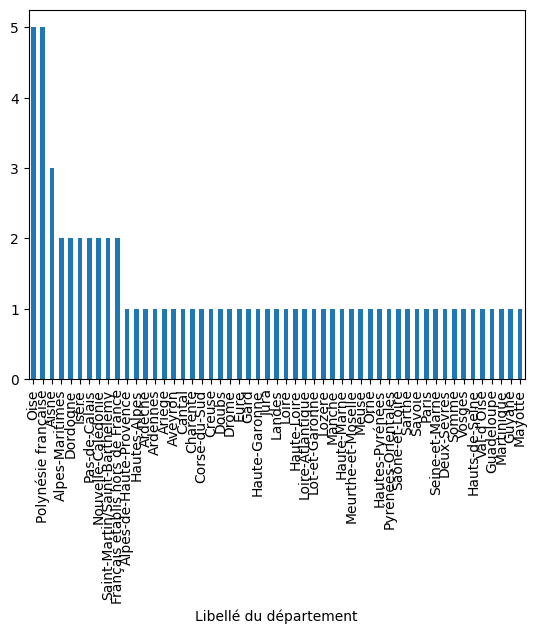

In [11]:
# Voir la répartition par département de ces lignes à 0
df_election[df_election['Exprimés'] == 0]['Libellé du département'].value_counts().plot(kind='bar')

### Les bureaux de vote affichant 0 voix exprimées sont retirés du dataset : l'absence de données électorales exploitables sur ces lignes introduirait du bruit et fausserait l'apprentissage du modèle.

In [12]:
# ==========================================
# ÉTAPE 1 : AGRÉGATION (Fusion des bureaux de vote)
# ==========================================

# On repère automatiquement toutes les colonnes de résultats (celles qui commencent par 'voix_')
cols_voix = [col for col in df_clean.columns if col.startswith('voix_')]

# On définit toutes les colonnes qu'on veut additionner
cols_numeriques = ['Inscrits', 'Abstentions', 'Votants', 'Blancs', 'Nuls', 'Exprimés']
cols_a_sommer = cols_numeriques + cols_voix

# Le groupby : On rassemble toutes les lignes qui ont la même commune.
# Le .reset_index() à la fin est crucial : il transforme le résultat en un DataFrame classique
df_communes = df_clean.groupby([
    'Code du département', 
    'Libellé du département', 
    'Code de la commune', 
    'Libellé de la commune'
])[cols_a_sommer].sum().reset_index()


# ==========================================
# ÉTAPE 2 : CRÉATION DU CODE INSEE (La clé de voûte)
# ==========================================

# On s'assure que le département est au format texte (string)
dept = df_communes['Code du département'].astype(str)

# On s'assure que le code commune est au format texte ET fait exactement 3 caractères (.str.zfill(3))
# Exemple : "4" devient "004", "12" devient "012", "154" reste "154"
comm = df_communes['Code de la commune'].astype(str).str.zfill(3)

# On concatène (fusionne) les deux pour créer la clé officielle
df_communes['Code_INSEE'] = dept + comm

# Juste avant de calculer les pourcentages à l'étape 3 :
initial_count = len(df_communes)

# On ne garde que les communes qui ont au moins 1 inscrit ET au moins 1 exprimé
df_communes = df_communes[(df_communes['Inscrits'] > 0) & (df_communes['Exprimés'] > 0)].copy()

deleted_count = initial_count - len(df_communes)
print(f"Nettoyage : {deleted_count} communes supprimées (données incomplètes ou nulles).")

# ==========================================
# ÉTAPE 3 : CALCUL DES POURCENTAGES (Pour le Machine Learning)
# ==========================================

# On boucle sur la liste des candidats qu'on a créée à l'étape 1
for col_voix in cols_voix:
    # On génère un nouveau nom de colonne. Ex: 'voix_MACRON' devient 'pct_MACRON'
    nom_col_pct = col_voix.replace('voix_', 'pct_')
    
    # La formule mathématique vectorisée
    # On gère le cas (très rare) où Exprimés = 0 pour éviter une division par zéro qui ferait planter le code
    df_communes[nom_col_pct] = (df_communes[col_voix] / df_communes['Exprimés'] * 100).fillna(0).round(2)


# ==========================================
# ÉTAPE 4 : NETTOYAGE FINAL (L'esthétique)
# ==========================================

# On réorganise les colonnes pour mettre le Code_INSEE tout devant, c'est plus pratique à lire
toutes_les_colonnes = df_communes.columns.tolist()
# On enlève le Code_INSEE de sa position actuelle (tout à la fin)...
toutes_les_colonnes.remove('Code_INSEE')
# ... pour le remettre au tout début
colonnes_finales = ['Code_INSEE'] + toutes_les_colonnes

df_final = df_communes[colonnes_finales]


df_final.head().columns

Nettoyage : 16 communes supprimées (données incomplètes ou nulles).


Index(['Code_INSEE', 'Code du département', 'Libellé du département',
       'Code de la commune', 'Libellé de la commune', 'Inscrits',
       'Abstentions', 'Votants', 'Blancs', 'Nuls', 'Exprimés', 'voix_ARTHAUD',
       'voix_ROUSSEL', 'voix_MACRON', 'voix_LASSALLE', 'voix_LE PEN',
       'voix_ZEMMOUR', 'voix_MÉLENCHON', 'voix_HIDALGO', 'voix_JADOT',
       'voix_PÉCRESSE', 'voix_POUTOU', 'voix_DUPONT-AIGNAN', 'pct_ARTHAUD',
       'pct_ROUSSEL', 'pct_MACRON', 'pct_LASSALLE', 'pct_LE PEN',
       'pct_ZEMMOUR', 'pct_MÉLENCHON', 'pct_HIDALGO', 'pct_JADOT',
       'pct_PÉCRESSE', 'pct_POUTOU', 'pct_DUPONT-AIGNAN'],
      dtype='str')

### Nous allons construire le DataFrame prêt à la fusion avec les données INSEE, en agrégeant la cible par familles politiques (Gauche, Centre, Droite) et en conservant les clés de jointure nécessaires.

In [13]:
# On prépare la base avec les chiffres bruts nécessaires
df_blocs = df_final[[
    'Code_INSEE', 
    'Libellé de la commune', 
    'Inscrits', 
    'Abstentions', 
    'Votants', 
    'Blancs', 
    'Nuls', 
    'Exprimés'
]].copy()

# 1. L'abstention (sur les inscrits)
df_blocs['pct_abstention'] = (df_blocs['Abstentions'] / df_blocs['Inscrits'] * 100).round(2)

# 2. Le vote blanc (sur les votants) - Geste politique de refus
df_blocs['pct_blancs'] = (df_blocs['Blancs'] / df_blocs['Votants'] * 100).round(2)

# 3. Le vote nul (sur les votants) - Souvent une erreur ou une radiation
df_blocs['pct_nuls'] = (df_blocs['Nuls'] / df_blocs['Votants'] * 100).round(2)

groupes = {
    'gauche': ['voix_ARTHAUD', 'voix_ROUSSEL', 'voix_MÉLENCHON', 'voix_HIDALGO', 'voix_JADOT', 'voix_POUTOU'],
    'centre': ['voix_MACRON', 'voix_LASSALLE'],
    'droite': ['voix_LE PEN', 'voix_ZEMMOUR', 'voix_PÉCRESSE', 'voix_DUPONT-AIGNAN']
}

for nom_bloc, liste_candidats in groupes.items():
    # On fait la somme des voix du bloc pour chaque commune
    total_voix_bloc = df_final[liste_candidats].sum(axis=1)
    # On calcule le pourcentage sur les EXPRIMÉS
    df_blocs[f'pct_{nom_bloc}'] = (total_voix_bloc / df_blocs['Exprimés'] * 100).round(2)

In [14]:
df_blocs.head()

,Code_INSEE,Libellé de la commune,Inscrits,Abstentions,Votants,Blancs,Nuls,Exprimés,pct_abstention,pct_blancs,pct_nuls,pct_gauche,pct_centre,pct_droite
0,01001,L'Abergement-Clémenciat,645,108,537,16,1,520,16.74,2.98,0.19,21.73,32.31,45.96
1,01002,L'Abergement-de-Varey,213,38,175,3,1,171,17.84,1.71,0.57,38.60,35.09,26.32
2,01004,Ambérieu-en-Bugey,8765,2078,6687,88,46,6553,23.71,1.32,0.69,34.44,24.87,40.68
3,01005,Ambérieux-en-Dombes,1282,234,1048,14,6,1028,18.25,1.34,0.57,21.50,29.47,49.03
4,01006,Ambléon,103,23,80,3,0,77,22.33,3.75,0.00,32.47,29.87,37.66


In [ ]:
# Export des datasets
df_blocs.to_csv('src/election.csv', index=False, sep=';', encoding='utf-8')

/tmp/ipykernel_7808/3319462259.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=stats_blocs.index, y=stats_blocs.values, palette=['coral', 'royalblue', 'gold'])


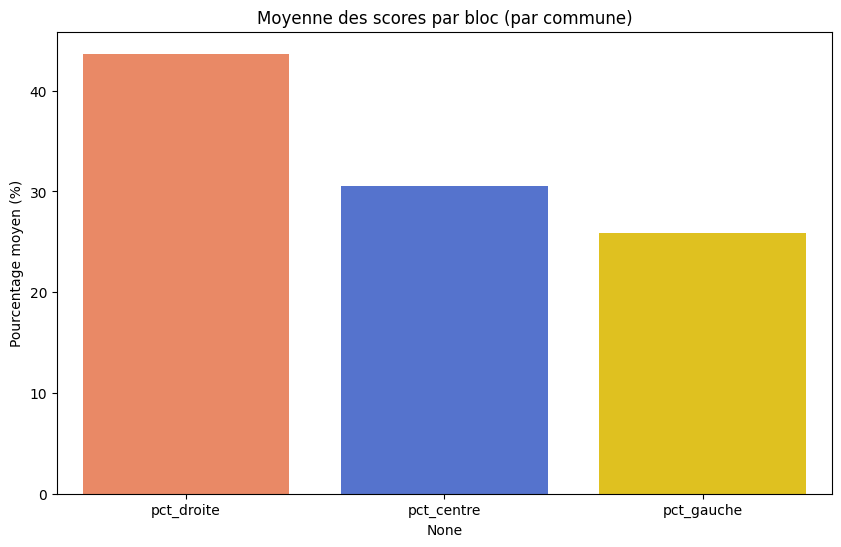

In [15]:
# On prépare les données : on fait la moyenne des % de chaque commune
stats_blocs = df_blocs[['pct_gauche', 'pct_centre', 'pct_droite']].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=stats_blocs.index, y=stats_blocs.values, palette=['coral', 'royalblue', 'gold'])
plt.title('Moyenne des scores par bloc (par commune)')
plt.ylabel('Pourcentage moyen (%)')
plt.show()

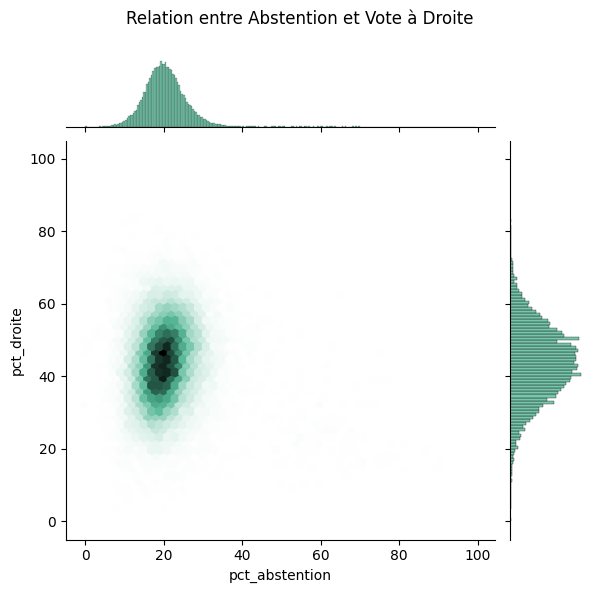

In [16]:
# Exemple avec le bloc Droite
sns.jointplot(data=df_blocs, x='pct_abstention', y='pct_droite', kind="hex", color="#4CB391")
plt.subplots_adjust(top=0.9)
plt.suptitle('Relation entre Abstention et Vote à Droite')
plt.show()

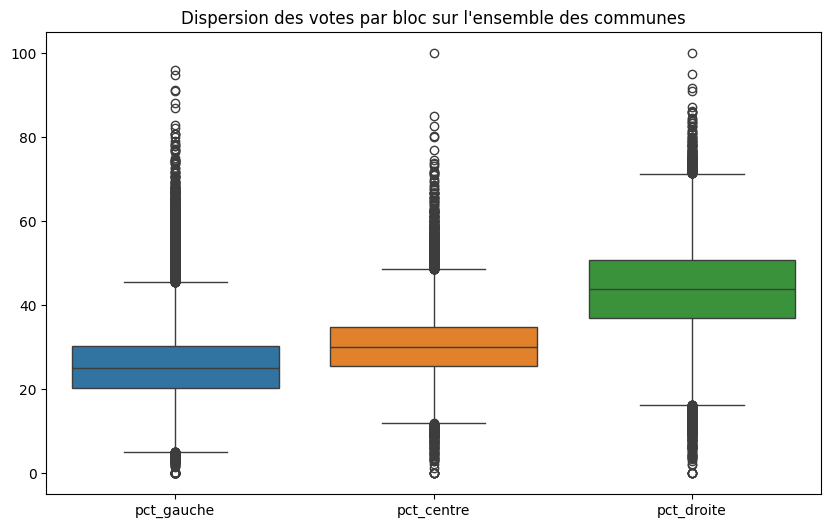

In [17]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_blocs[['pct_gauche', 'pct_centre', 'pct_droite']])
plt.title('Dispersion des votes par bloc sur l\'ensemble des communes')
plt.show()

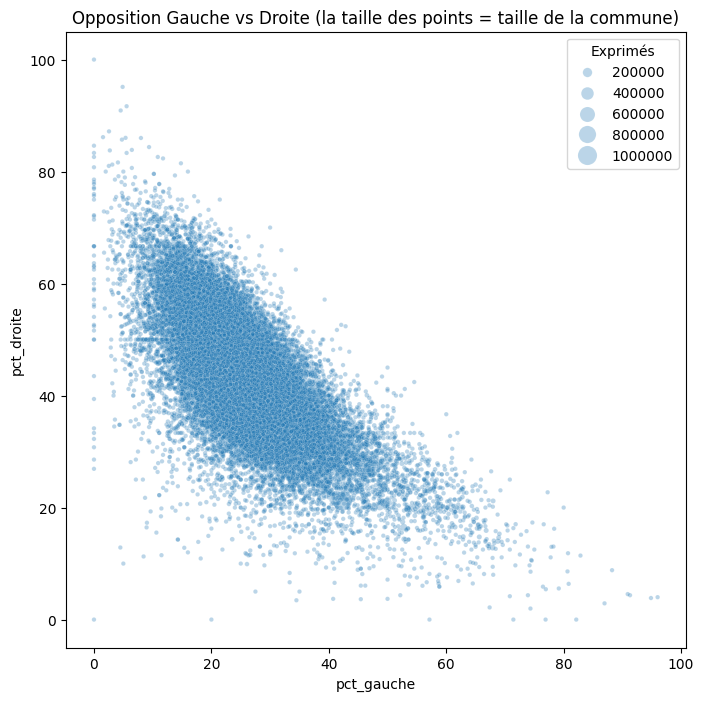

In [18]:
plt.figure(figsize=(8, 8))
sns.scatterplot(data=df_blocs, x='pct_gauche', y='pct_droite', alpha=0.3, size='Exprimés', sizes=(10, 200))
plt.title('Opposition Gauche vs Droite (la taille des points = taille de la commune)')
plt.show()

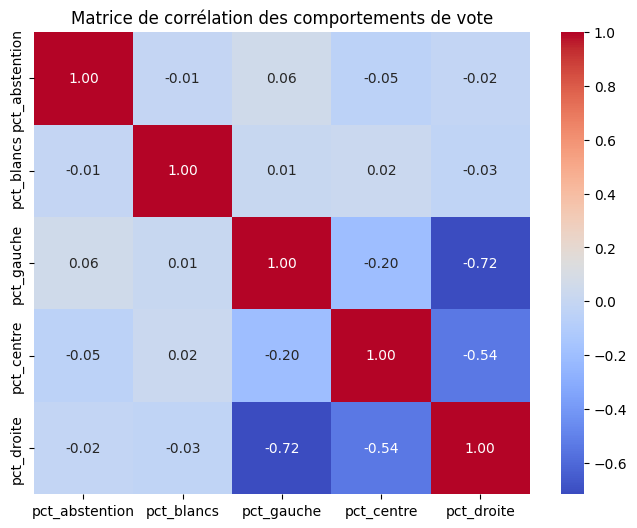

In [19]:
# On sélectionne les colonnes numériques
cols_etude = ['pct_abstention', 'pct_blancs', 'pct_gauche', 'pct_centre', 'pct_droite']
corr = df_blocs[cols_etude].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matrice de corrélation des comportements de vote')
plt.show()

In [ ]:
# 1. Référentiel
url_coords = "https://www.data.gouv.fr/fr/datasets/r/dbe8a621-a9c4-4bc3-9cae-be1699c5ff25"
df_coords = pd.read_csv(url_coords, sep=',', dtype=str)

# Sélection des bonnes colonnes identifiées
df_coords = df_coords[['code_commune_INSEE', 'nom_commune_postal', 'latitude', 'longitude']].copy()

# Conversion numérique (errors='coerce' transformera les textes invalides en NaN)
df_coords['latitude'] = pd.to_numeric(df_coords['latitude'], errors='coerce')
df_coords['longitude'] = pd.to_numeric(df_coords['longitude'], errors='coerce')

# 2. Préparation
df_blocs['Code_INSEE'] = df_blocs['Code_INSEE'].astype(str).str.zfill(5)

# 3. Fusion
df_final = pd.merge(
    df_blocs, 
    df_coords, 
    left_on='Code_INSEE', 
    right_on='code_commune_INSEE', 
    how='inner'
)

# --- ETAPE CRUCIALE : Nettoyage des NaN ---
df_final = df_final.dropna(subset=['latitude', 'longitude'])
# ------------------------------------------

# 4. Création de la carte
m = folium.Map(location=[46.2276, 2.2137], zoom_start=6, tiles='cartodbpositron')

for index, row in df_final.iterrows():
    # On vérifie pct_gauche (assure-toi que c'est un nombre aussi)
    valeur_vote = float(row['pct_gauche'])
    
    if valeur_vote > 2:
        folium.CircleMarker(
            location=[row['latitude'], row['longitude']],
            radius=1.5,
            color=None,
            fill=True,
            fill_color='red',
            fill_opacity=min(valeur_vote / 100 * 1.5, 1.0), # Petit boost d'opacité pour le visuel
            tooltip=f"{row['nom_commune_postal']} : {valeur_vote}%"
        ).add_to(m)

m.save("carte_cercles_communes.html")
print(f"Carte générée avec {len(df_final)} points !")

Carte générée avec 34284 points !


In [ ]:
# 1. Calculer le bloc gagnant et sa couleur
def get_color(row):
    # On compare les 3 colonnes
    scores = {
        'red': row['pct_gauche'],
        'orange': row['pct_centre'],
        'blue': row['pct_droite']
    }
    # On retourne la couleur de la clé qui a la valeur max
    return max(scores, key=scores.get)

# On applique la fonction
df_final['couleur_gagnante'] = df_final.apply(get_color, axis=1)

# 2. Création de la carte
m = folium.Map(location=[46.2276, 2.2137], zoom_start=6, tiles='cartodbpositron')

for index, row in df_final.iterrows():
    # On récupère le score max pour l'opacité
    score_max = max(row['pct_gauche'], row['pct_centre'], row['pct_droite'])
    
    folium.CircleMarker(
        location=[row['latitude'], row['longitude']],
        radius=1.8, # Un peu plus gros pour boucher les "trous" visuels
        color=None,
        fill=True,
        fill_color=row['couleur_gagnante'],
        # Plus le score est élevé, plus la couleur est vive
        fill_opacity=min(score_max / 100 * 1.2, 1.0), 
        tooltip=(f"<b>{row['nom_commune_postal']}</b><br>"
                 f"Gauche: {row['pct_gauche']}%<br>"
                 f"Centre: {row['pct_centre']}%<br>"
                 f"Droite: {row['pct_droite']}%")
    ).add_to(m)

m.save("carte_electorale_couleurs.html")

In [ ]:
def fetch_unemployment_data():
    # URL du dataset "Taux de chômage localisé par département" sur data.gouv.fr
    # On cible ici l'API de ressources pour un fichier CSV spécifique
    dataset_id = "5a27f000c751df1303862618" # Exemple d'ID pour le chômage
    api_url = f"https://www.data.gouv.fr/api/1/datasets/{dataset_id}/"
    
    try:
        response = requests.get(api_url)
        response.raise_for_status()
        data = response.json()
        
        # On cherche le fichier le plus récent dans les ressources
        latest_resource = data['resources'][0] # Souvent le premier est le plus récent
        csv_url = latest_resource['latest']
        
        print(f"Téléchargement des données depuis : {csv_url}")
        
        # Lecture du CSV avec Pandas
        df = pd.read_csv(csv_url, sep=';') # Attention au séparateur souvent ';' en FR
        
        # Nettoyage rapide (exemple)
        # On garde le code département et le taux du dernier trimestre connu
        cols_to_keep = [df.columns[0], df.columns[-1]] 
        df_clean = df[cols_to_keep]
        df_clean.columns = ['code_dept', 'taux_chomage_recent']
        
        return df_clean

    except Exception as e:
        print(f"Erreur lors de la récupération : {e}")
        return None

# Utilisation
df_chomage = fetch_unemployment_data()
if df_chomage is not None:
    print(df_chomage.head())

Erreur lors de la récupération : 404 Client Error: NOT FOUND for url: https://www.data.gouv.fr/api/1/datasets/5a27f000c751df1303862618/
